In [57]:
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import _tree  # <-- added
import yaml

In [22]:
# ------------------------------
# User-controlled "large value" threshold
# All rows with target >= this quantile are marked interesting
high_value_quantile = 0.94  # top 5%; lower this to get more "interesting" rows
# ------------------------------
# Step 1: Download/Load the California Housing dataset and save as CSV
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
# df = pd.read_csv(url)

# For adaptability: specify the regression target column name
target_col = 'MedHouseVal'

# Save to CSV
df.to_csv('california_housing.csv', index=False)




In [23]:

# Step 2: Read the data from CSV (simulates downloading and reading)
df = pd.read_csv('california_housing.csv')

# Extract the target as a 1D array reshaped for clustering
X = df[target_col].values.reshape(-1, 1)


In [ ]:
# Step 3-5: Perform hierarchical clustering on the target only
method = 'single'
Z = linkage(X, method=method)

# Automatically determine threshold: find the largest jump in merge heights
heights = Z[:, 2]
diffs = np.diff(heights)
if len(diffs) > 0:
    max_diff_idx = np.argmax(diffs)
    threshold = heights[max_diff_idx]  # Cut before the largest gap
else:
    threshold = np.max(heights) if len(heights) > 0 else 0  # Fallback for small data

# Form flat clusters based on the distance threshold
clusters = fcluster(Z, t=threshold, criterion='distance')

# Identify the largest cluster (the "normal" dense group)
unique_clusters, counts = np.unique(clusters, return_counts=True)
largest_cluster_label = unique_clusters[np.argmax(counts)]

# Base: interesting if NOT in largest cluster
interesting_mask = (clusters != largest_cluster_label)

# ---------------------------------------
# NEW: enforce that very large values are interesting
# ---------------------------------------
high_value_cutoff = df[target_col].quantile(high_value_quantile)
interesting_mask |= df[target_col] >= high_value_cutoff

# Step 6: Create new column
df['is_interesting_subgroup'] = interesting_mask

# Step 7: Save the updated DataFrame as a new CSV
df.to_csv('california_housing_with_interesting.csv', index=False)

# Optional: Print summary for verification
print(f"Threshold (clustering) used: {threshold}")
print(f"Largest cluster label: {largest_cluster_label}")
print(f"High-value quantile: {high_value_quantile}")
print(f"High-value cutoff: {high_value_cutoff}")
print(f"Number of interesting rows: {df['is_interesting_subgroup'].sum()}")
print("Updated CSV saved as 'california_housing_with_interesting.csv'")



Threshold (clustering) used: 0.025009999999999977
Largest cluster label: 1
High-value quantile: 0.94
High-value cutoff: 4.521
Number of interesting rows: 1246
Updated CSV saved as 'california_housing_with_interesting.csv'


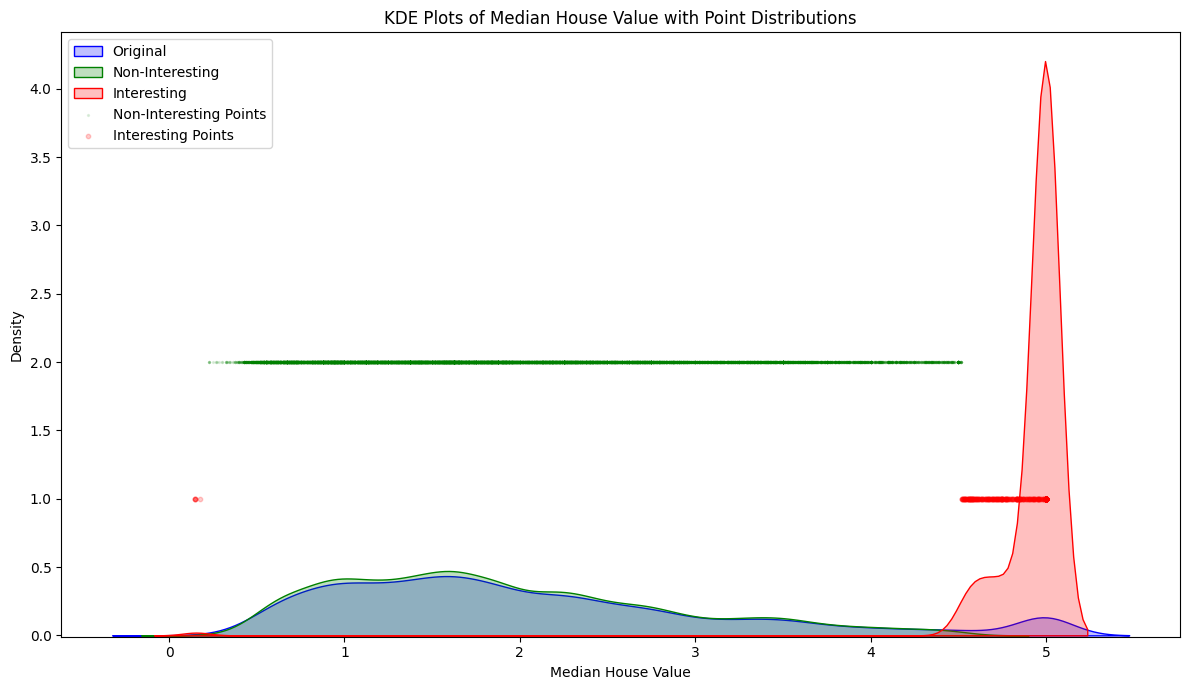

In [ ]:
import seaborn as sns
df = pd.read_csv('california_housing_with_interesting.csv')

target_col = 'MedHouseVal'

# Subsets
interesting = df[df['is_interesting_subgroup'] == True]
non_interesting = df[df['is_interesting_subgroup'] == False]

plt.figure(figsize=(12, 7))

# KDE plots
sns.kdeplot(df[target_col], color='blue', fill=True, alpha=0.25, label='Original')
sns.kdeplot(non_interesting[target_col], color='green', fill=True, alpha=0.25, label='Non-Interesting')
sns.kdeplot(interesting[target_col], color='red', fill=True, alpha=0.25, label='Interesting')

# ----------------------------------------------------
# SCATTER POINTS ON OFFSET Y-AXES
# ----------------------------------------------------

# Offsets to stack the points visually
y_noninteresting = np.full(len(non_interesting), 2.)   # slight shift below x-axis
y_interesting    = np.full(len(interesting),  1.)       # slight shift above x-axis

# Plot scatter points
plt.scatter(
    non_interesting[target_col],
    y_noninteresting,
    color='green',
    alpha=0.1,
    s=2,
    label='Non-Interesting Points'
)

plt.scatter(
    interesting[target_col],
    y_interesting,
    color='red',
    alpha=0.2,
    s=10,
    label='Interesting Points'
)

# -----------------------------------------
# Formatting
# -----------------------------------------
plt.title("KDE Plots of Median House Value with Point Distributions")
plt.xlabel("Median House Value")
plt.ylabel("Density")

# Hide y values around 0 (scatter offsets)
plt.ylim(-0.01, None)

# Avoid duplicate label entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.savefig("house_value_kde_improved.jpg", dpi=300)
plt.show()


In [54]:
# 1) Read the new CSV file
data_path = 'california_housing_with_interesting.csv'  # Upload to Colab or place in working dir
df = pd.read_csv(data_path)

target_col = 'is_interesting_subgroup'

# EXCLUDE both the target and the original regression target "MedHouseVal"
feature_cols = [c for c in df.columns if c not in [target_col, 'MedHouseVal']]

X = df[feature_cols].values
y = df[target_col].astype(int).values  # binary labels 0/1


# -------------------------------------------------------------------
# Prune subtrees whose leaves all predict the same class
# -------------------------------------------------------------------
def prune_pure_subtrees(tree: DecisionTreeClassifier) -> None:
    """
    In-place pruning: if all leaves in a subtree predict the same class,
    collapse the whole subtree into a single leaf node without
    changing the tree's predictions.
    """
    tree_ = tree.tree_

    def recurse(node_id: int):
        # Leaf -> return its predicted class index
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            return {class_index}

        # Recurse into children
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        left_classes = recurse(left_id)
        right_classes = recurse(right_id)

        union = left_classes | right_classes

        # If all leaves below predict the same class, prune here
        if len(union) == 1:
            tree_.children_left[node_id] = -1
            tree_.children_right[node_id] = -1
            tree_.feature[node_id] = _tree.TREE_UNDEFINED
            tree_.threshold[node_id] = -2.0
            # Keep tree_.value[node_id] as-is; argmax stays consistent
        return union

    recurse(0)


# -------------------------------------------------------------------
# Count decision questions in a tree
# -------------------------------------------------------------------
def count_questions(tree: DecisionTreeClassifier) -> int:
    tree_ = tree.tree_
    children_left = tree_.children_left
    children_right = tree_.children_right

    # Count only reachable internal nodes (questions) from the root
    def dfs(node_id: int) -> int:
        if node_id == -1:
            return 0
        # leaf
        if children_left[node_id] == -1 and children_right[node_id] == -1:
            return 0
        # internal node
        return 1 + dfs(children_left[node_id]) + dfs(children_right[node_id])

    return int(dfs(0))


# -------------------------------------------------------------------
# YAML export including human-readable questions
# -------------------------------------------------------------------
def tree_to_dict(tree: DecisionTreeClassifier, feature_names):
    """
    Export a sklearn DecisionTreeClassifier into a nested dict for YAML,
    including a readable 'question' field.
    """
    tree_ = tree.tree_
    feature = tree_.feature
    threshold = tree_.threshold

    def recurse(node_id: int):
        # Leaf node
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            class_label = int(tree.classes_[class_index])
            return {
                'leaf_prediction': class_label,
                'class_counts': value.tolist(),
            }

        # Internal decision node
        feat_name = feature_names[feature[node_id]]
        thresh = float(threshold[node_id])

        return {
            'question': f"{feat_name} <= {thresh}",
            'feature': feat_name,
            'threshold': thresh,
            'left': recurse(tree_.children_left[node_id]),
            'right': recurse(tree_.children_right[node_id]),
        }

    return recurse(0)


# -------------------------------------------------------------------
# Build + evaluate forest (small random forest with constraints)
# -------------------------------------------------------------------
def build_and_evaluate_forest(seed: int):
    """
    Build a small random forest and evaluate on training data.
    For each seed:
      - maximal number of trees ~ Uniform{1,...,10}
      - maximal number of questions per tree ~ Uniform{2,...,10}
    Forest rule: interesting if ANY tree predicts interesting.
    Deterministic for a given seed.
    """
    rng = np.random.RandomState(seed)

    n_samples = X.shape[0]

    # Draw per-seed maxima (deterministic for the seed)
    max_n_trees = rng.randint(1, 11)   # 1..10 inclusive
    max_questions = rng.randint(2, 11) # 2..10 inclusive

    n_trees = max_n_trees

    trees = []
    tree_accuracies = []
    tree_question_counts = []

    print(f"Seed {seed} - max_n_trees={max_n_trees}, max_questions_per_tree={max_questions}")

    for tree_idx in range(n_trees):
        # Bootstrap sample
        bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[bootstrap_indices]
        y_boot = y[bootstrap_indices]

        # Each tree has at most max_questions internal decision nodes.
        # Using max_leaf_nodes = max_questions + 1 ensures internal nodes <= max_questions
        tree_random_state = rng.randint(0, 1_000_000)
        clf = DecisionTreeClassifier(
            max_leaf_nodes=max_questions + 1,
            random_state=tree_random_state,
        )
        clf.fit(X_boot, y_boot)

        # Prune subtrees that don't change predictions
        prune_pure_subtrees(clf)

        # Evaluate tree on full training set
        y_pred_tree = clf.predict(X)
        acc_tree = (y_pred_tree == y).mean()

        # Count questions
        n_questions = count_questions(clf)

        print(f"  Tree {tree_idx}: accuracy={acc_tree:.4f}, questions={n_questions}")

        # Store results
        trees.append(clf)
        tree_accuracies.append(acc_tree)
        tree_question_counts.append(n_questions)

        # Save YAML tree
        tree_dict = tree_to_dict(clf, feature_names=feature_cols)
        tree_filename = f"tree_seed{seed}_tree{tree_idx}.yml"
        with open(tree_filename, 'w') as f:
            yaml.dump(tree_dict, f)

    # -------------------------------------------------------------------
    # Forest prediction = OR of all trees' predictions
    # -------------------------------------------------------------------
    all_tree_preds = []
    for clf in trees:
        preds = clf.predict(X)
        all_tree_preds.append(preds.astype(bool))

    pred_matrix = np.vstack(all_tree_preds)
    forest_pred = np.any(pred_matrix, axis=0).astype(int)

    forest_accuracy = (forest_pred == y).mean()
    total_questions = int(np.sum(tree_question_counts))

    print(f"Seed {seed} - Forest accuracy={forest_accuracy:.4f}, "
          f"n_trees={n_trees}, total_questions={total_questions}")
    print("-" * 60)

    return {
        'seed': seed,
        'forest_accuracy': forest_accuracy,
        'n_trees': n_trees,
        'total_questions': total_questions,
    }

In [55]:
# -------------------------------------------------------------------
# Run for 100 seeds and save results
# -------------------------------------------------------------------
results = []
seeds = list(range(1000))  # 0..99

for s in seeds:
    metrics = build_and_evaluate_forest(s)
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df.to_csv('results.csv', index=False)

print("\nSummary of forests:")
print(results_df)


Seed 0 - max_n_trees=6, max_questions_per_tree=2
  Tree 0: accuracy=0.9524, questions=1
  Tree 1: accuracy=0.9525, questions=1
  Tree 2: accuracy=0.9523, questions=1
  Tree 3: accuracy=0.9525, questions=2
  Tree 4: accuracy=0.9518, questions=1
  Tree 5: accuracy=0.9540, questions=2
Seed 0 - Forest accuracy=0.9518, n_trees=6, total_questions=8
------------------------------------------------------------
Seed 1 - max_n_trees=6, max_questions_per_tree=10
  Tree 0: accuracy=0.9583, questions=7
  Tree 1: accuracy=0.9592, questions=10
  Tree 2: accuracy=0.9594, questions=6
  Tree 3: accuracy=0.9594, questions=10
  Tree 4: accuracy=0.9599, questions=7
  Tree 5: accuracy=0.9575, questions=7
Seed 1 - Forest accuracy=0.9582, n_trees=6, total_questions=47
------------------------------------------------------------
Seed 2 - max_n_trees=9, max_questions_per_tree=10
  Tree 0: accuracy=0.9584, questions=10
  Tree 1: accuracy=0.9579, questions=7
  Tree 2: accuracy=0.9591, questions=7
  Tree 3: accura

Best forest (based on 75% rule and minimal questions):
seed               703.000000
forest_accuracy      0.960223
n_trees              1.000000
total_questions      8.000000
Name: 703, dtype: float64

Rebuilt forest with seed=703
  Number of trees: 1
  Max questions per tree (constraint): 10


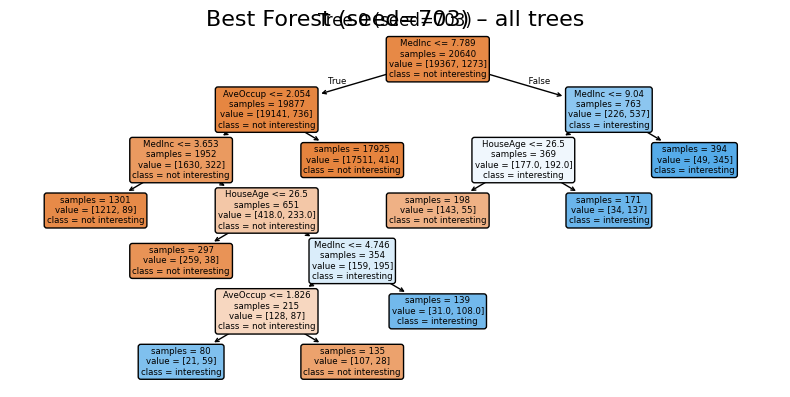

Saved forest visualization as best_forest_all_trees.jpg


In [58]:
# 1) Load the results
results_df = pd.read_csv("results.csv")

# 2) Find accuracy threshold: better than 75% of all models
acc_threshold = results_df["forest_accuracy"].quantile(0.99)

# Forests strictly better than 75% of all
top_df = results_df[results_df["forest_accuracy"] > acc_threshold]

# Fallback: if none strictly greater, allow >=
if top_df.empty:
    top_df = results_df[results_df["forest_accuracy"] >= acc_threshold]

# 3) Among these, choose the one with:
#    - smallest total_questions
#    - if tie: highest forest_accuracy
#    - if tie again: smallest seed
top_sorted = top_df.sort_values(
    by=["total_questions", "forest_accuracy", "seed"],
    ascending=[True, False, True]
)

best_row = top_sorted.iloc[0]
best_seed = int(best_row["seed"])

print("Best forest (based on 75% rule and minimal questions):")
print(best_row)


# --- added: same pruning helper as in training code ---
def prune_pure_subtrees(tree: DecisionTreeClassifier) -> None:
    """
    In-place pruning: if all leaves in a subtree predict the same class,
    collapse the whole subtree into a single leaf node without
    changing the tree's predictions.
    """
    tree_ = tree.tree_

    def recurse(node_id: int):
        # Leaf -> return its predicted class index
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            return {class_index}

        # Recurse into children
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        left_classes = recurse(left_id)
        right_classes = recurse(right_id)

        union = left_classes | right_classes

        # If all leaves below predict the same class, prune here
        if len(union) == 1:
            tree_.children_left[node_id] = -1
            tree_.children_right[node_id] = -1
            tree_.feature[node_id] = _tree.TREE_UNDEFINED
            tree_.threshold[node_id] = -2.0
            # Keep tree_.value[node_id] as-is; argmax stays consistent
        return union

    recurse(0)
# --- end added helper ---


# 4) Rebuild the forest for this seed (deterministically, same logic as training)
def rebuild_forest_for_seed(seed: int):
    """
    Rebuilds the forest for the given seed using the same logic
    as the training code, and returns the list of trees and the
    per-seed max_questions used.
    """
    rng = np.random.RandomState(seed)
    n_samples = X.shape[0]

    # Same per-seed maxima as in the training cell
    max_n_trees = rng.randint(1, 11)   # 1..10 inclusive
    max_questions = rng.randint(2, 11) # 2..10 inclusive

    n_trees = max_n_trees

    trees = []

    for tree_idx in range(n_trees):
        # Bootstrap sample
        bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[bootstrap_indices]
        y_boot = y[bootstrap_indices]

        # Same constraint: at most max_questions internal decision nodes
        tree_random_state = rng.randint(0, 1_000_000)
        clf = DecisionTreeClassifier(
            max_leaf_nodes=max_questions + 1,
            random_state=tree_random_state,
        )
        clf.fit(X_boot, y_boot)
        prune_pure_subtrees(clf)  # <-- added: prune to match training behavior
        trees.append(clf)

    return trees, max_questions


trees, max_questions = rebuild_forest_for_seed(best_seed)
n_trees = len(trees)

print(f"\nRebuilt forest with seed={best_seed}")
print(f"  Number of trees: {n_trees}")
print(f"  Max questions per tree (constraint): {max_questions}")


# 5) Visualize the entire forest (all trees) in one figure
if n_trees == 1:
    n_cols = 1
else:
    n_cols = 2  # up to 2 trees per row for readability
n_rows = int(np.ceil(n_trees / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 4 * n_rows))

# Make axes iterable in a flat array
if n_trees == 1:
    axes = np.array([axes])
else:
    axes = np.array(axes).reshape(-1)

for idx, (clf, ax) in enumerate(zip(trees, axes)):
    plot_tree(
        clf,
        feature_names=feature_cols,
        class_names=["not interesting", "interesting"],
        filled=True,
        rounded=True,
        impurity=False,
        ax=ax
    )
    ax.set_title(f"Tree {idx} (seed={best_seed})")

# Hide any unused axes (if n_trees is odd)
for ax in axes[n_trees:]:
    ax.axis("off")

fig.suptitle(f"Best Forest (seed={best_seed}) – all trees", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save as JPG
plt.savefig("best_forest_all_trees.jpg", dpi=300, bbox_inches="tight")

# Show inline
plt.show()

print("Saved forest visualization as best_forest_all_trees.jpg")


In [59]:
import subprocess
import sys

# -----------------------------------------------------------
# 0) Check if Graphviz is installed — install only if needed
# -----------------------------------------------------------
need_install = False
try:
    import graphviz
except ImportError:
    need_install = True

if need_install:
    print("Graphviz not found — installing...")
    # Install OS-level graphviz first
    subprocess.run(["apt-get", "update"])
    subprocess.run(["apt-get", "install", "-y", "graphviz"])
    # Install Python package
    subprocess.run([sys.executable, "-m", "pip", "install", "graphviz"])

# After installation, import again
import graphviz
from graphviz import Digraph

import pandas as pd
import numpy as np
import yaml
import os
from math import ceil
from IPython.display import Image, display


# -----------------------------------------------------------
# 1) Load forest-level results
# -----------------------------------------------------------
results_df = pd.read_csv("results.csv")

# 2) Determine accuracy threshold (75%)
acc_threshold = results_df["forest_accuracy"].quantile(0.99)

# Forests strictly above threshold
top_df = results_df[results_df["forest_accuracy"] > acc_threshold]
if top_df.empty:
    # fallback: allow >=
    top_df = results_df[results_df["forest_accuracy"] >= acc_threshold]

# 3) Pick best forest using:
#    lowest total_questions → highest accuracy → lowest seed
top_sorted = top_df.sort_values(
    by=["total_questions", "forest_accuracy", "seed"],
    ascending=[True, False, True]
)

best_row = top_sorted.iloc[0]
best_seed = int(best_row["seed"])

print("Best forest (from results.csv):")
print(best_row)


# -----------------------------------------------------------
# 4) Load *all* YAML trees for this best forest
# -----------------------------------------------------------
yaml_files = sorted(
    f for f in os.listdir(".")
    if f.startswith(f"tree_seed{best_seed}_tree") and f.endswith(".yml")
)

trees_yaml = []
for fname in yaml_files:
    with open(fname, "r") as fh:
        trees_yaml.append(yaml.safe_load(fh))

n_trees = len(trees_yaml)
print(f"\nFound {n_trees} trees for forest with seed={best_seed}.")


# -----------------------------------------------------------
# 5) Build a Graphviz graph from YAML
# -----------------------------------------------------------
def build_graphviz_from_yaml(tree_yaml, name="tree"):
    """
    Convert YAML tree structure into a Graphviz Digraph.

    Coloring rules:
      - Internal node = white
      - Leaf pred=0 (non-interesting) = blue
      - Leaf pred=1 (interesting)     = red
    """
    dot = Digraph(name=name)
    dot.attr("node", shape="box", style="filled,rounded", fontsize="10")

    node_counter = [0]

    def next_id():
        nid = f"n{node_counter[0]}"
        node_counter[0] += 1
        return nid

    def recurse(node):
        nid = next_id()

        # Leaf
        if "leaf_prediction" in node:
            pred = node["leaf_prediction"]
            label = f"Leaf\npred={pred}"

            if pred == 0:
                fillcolor = "lightblue"
            else:
                fillcolor = "lightcoral"

            dot.node(nid, label=label, fillcolor=fillcolor)
            return nid

        # Internal decision node
        question = node.get("question", "")
        dot.node(nid, label=question, fillcolor="white")

        left_id = recurse(node["left"])
        right_id = recurse(node["right"])

        dot.edge(nid, left_id, label="True")
        dot.edge(nid, right_id, label="False")

        return nid

    recurse(tree_yaml)
    return dot


# -----------------------------------------------------------
# 6) Visualize all trees in the forest
# -----------------------------------------------------------
all_images = []

for idx, tree_yaml in enumerate(trees_yaml):
    print(f"\nRendering tree {idx}...")

    dot = build_graphviz_from_yaml(tree_yaml, name=f"bestforest_seed{best_seed}_tree{idx}")
    dot.format = "jpg"

    out_name = f"best_forest_seed{best_seed}_tree{idx}"
    filename = dot.render(out_name, cleanup=True)  # creates out_name + ".jpg"

    display(Image(filename))
    print(f"Saved tree {idx} → {filename}")


Graphviz not found — installing...


FileNotFoundError: [WinError 2] The system cannot find the file specified

NEW

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.tree import DecisionTreeClassifier, _tree
from scipy.stats import entropy
import math
import warnings

warnings.filterwarnings("ignore")

# 1. Load Data
housing = fetch_california_housing(as_frame=True)
df = housing.frame
target_col = 'MedHouseVal'

# Work with numpy array for speed
y_full = df[target_col].values
N = len(y_full)

print(f"Data loaded. Shape: {df.shape}")

Data loaded. Shape: (20640, 9)


In [40]:
def freedman_diaconis_bins(data):
    """Calculates bin edges using the Freedman-Diaconis rule."""
    data = np.asarray(data).ravel()
    if data.size < 2:
        return np.array([data.min(), data.max()])
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        nbins = max(1, int(np.sqrt(data.size)))
        return np.histogram_bin_edges(data, bins=nbins)
    h = 2 * iqr / (data.size ** (1/3))
    if h <= 0:
        nbins = max(1, int(np.sqrt(data.size)))
        return np.histogram_bin_edges(data, bins=nbins)
    nbins = int(math.ceil((data.max() - data.min()) / h))
    nbins = max(1, nbins)
    return np.histogram_bin_edges(data, bins=nbins)

def hist_kl(p_samples, q_samples, global_bins, eps=1e-9):
    """
    Calculates KL Divergence KL(P || Q) using fixed global bins.
    P: Subgroup distribution
    Q: Global/Reference distribution
    """
    p, q = np.asarray(p_samples).ravel(), np.asarray(q_samples).ravel()
    
    p_hist, _ = np.histogram(p, bins=global_bins, density=True)
    q_hist, _ = np.histogram(q, bins=global_bins, density=True)
    
    # Add epsilon for numerical stability
    p_prob = (p_hist + eps) / (p_hist.sum() + eps * len(p_hist))
    q_prob = (q_hist + eps) / (q_hist.sum() + eps * len(q_hist))
    
    return float(entropy(p_prob, q_prob))

# --- Configuration ---
n_seeds = 50       # Number of bootstrap seeds (Candidates). Increase to 1000 for full run.
beta = 0.5         # Size adjustment factor (alpha/gamma in Syflow paper)
lambd_div = 2.0    # Diversity weight lambda
n_select = 5       # Number of subgroups to select iteratively

# Pre-calculate global bins and distribution for consistent scoring
global_bins = freedman_diaconis_bins(y_full)

# --- A) Candidate Generation ---
print(f"Generating candidates over {n_seeds} seeds...")
candidates = []

for seed in range(n_seeds):
    # 1. Bootstrap Resampling
    np.random.seed(seed)
    sample_idx = np.random.choice(N, size=N, replace=True)
    y_boot = y_full[sample_idx].reshape(-1, 1)
    
    # 2. Clustering (Same approach as original notebook)
    # Using 'single' linkage on 1D data to find gaps/outliers
    try:
        Z = linkage(y_boot, method='single')
    except Exception:
        continue # Skip if clustering fails
        
    # Determine threshold (largest jump)
    heights = Z[:, 2]
    diffs = np.diff(heights)
    threshold = heights[np.argmax(diffs)] if len(diffs) > 0 else 0.0
    
    if threshold == 0: continue

    # 3. Apply Threshold to Bootstrap to find "Normal" range
    boot_clusters = fcluster(Z, t=threshold, criterion='distance')
    
    # Identify largest cluster as "Non-Interesting" (Normal)
    u_clusters, counts = np.unique(boot_clusters, return_counts=True)
    largest_label = u_clusters[np.argmax(counts)]
    
    # Get range of normal values in this bootstrap
    normal_vals = y_boot[boot_clusters == largest_label]
    if len(normal_vals) == 0: continue
    min_norm, max_norm = normal_vals.min(), normal_vals.max()
    
    # 4. Apply Rule to Full Data -> Candidate Mask
    # Subgroup = Points outside the "Normal" range of this seed
    mask = (y_full < min_norm) | (y_full > max_norm)
    
    # Filter trivial subgroups
    n_sub = mask.sum()
    if n_sub < 10 or n_sub > (N * 0.95): continue
    
    # 5. Pre-calculate Candidate Scores
    sub_y = y_full[mask]
    
    # KL(Subgroup || Global)
    kl_exc = hist_kl(sub_y, y_full, global_bins)
    
    # Size Term: (Size / Total)^beta
    size_term = (n_sub / N) ** beta
    
    # Quality Score = Size^beta * KL
    quality = size_term * kl_exc
    
    candidates.append({
        'seed': seed,
        'mask': mask,
        'y_values': sub_y,
        'size_term': size_term,
        'quality': quality,
        'selected': False
    })

print(f"Generated {len(candidates)} valid candidates.")

# --- B) Iterative Selection with Diversity (Syflow Objective) ---
selected_candidates = []
selected_indices = []

print(f"Selecting top {n_select} subgroups iteratively...")

for k in range(n_select):
    best_candidate = None
    best_score = -np.inf
    
    for cand in candidates:
        if cand['selected']:
            continue
            
        # Diversity Term: Average KL divergence between this candidate and already selected ones
        # Diversity(C) = (1/|S|) * Sum( KL(C || S_i) )
        diversity = 0.0
        if len(selected_candidates) > 0:
            for sel in selected_candidates:
                # KL(Candidate || Selected_i)
                diversity += hist_kl(cand['y_values'], sel['y_values'], global_bins)
            diversity /= len(selected_candidates)
        
        # Syflow Objective: Quality + Lambda * (Size_term * Diversity)
        # Note: We weight diversity by size_term as implied in methods.py/Syflow logic
        total_score = cand['quality'] + (lambd_div * cand['size_term'] * diversity)
        
        if total_score > best_score:
            best_score = total_score
            best_candidate = cand
            
    if best_candidate is None:
        break
        
    best_candidate['selected'] = True
    selected_candidates.append(best_candidate)
    print(f"  Selection {k+1}: Score={best_score:.4f} (Qual={best_candidate['quality']:.4f}, Div term contribution={(best_score - best_candidate['quality']):.4f})")

# --- C) Final Subgroup Construction ---
# Union of all selected subgroups
final_mask = np.zeros(N, dtype=bool)
for cand in selected_candidates:
    final_mask |= cand['mask']

df['is_interesting_subgroup'] = final_mask
df.to_csv('california_housing_with_interesting.csv', index=False)

print(f"\nFinal Interesting Subgroup Size: {final_mask.sum()} / {N} ({final_mask.mean()*100:.1f}%)")

Generating candidates over 50 seeds...
Generated 16 valid candidates.
Selecting top 5 subgroups iteratively...
  Selection 1: Score=0.1892 (Qual=0.1892, Div term contribution=0.0000)
  Selection 2: Score=0.1892 (Qual=0.1892, Div term contribution=0.0000)
  Selection 3: Score=0.1892 (Qual=0.1892, Div term contribution=0.0000)
  Selection 4: Score=0.1892 (Qual=0.1892, Div term contribution=0.0000)
  Selection 5: Score=0.1892 (Qual=0.1892, Div term contribution=0.0000)

Final Interesting Subgroup Size: 16 / 20640 (0.1%)


In [46]:
# --- A) Helper Functions ---
def freedman_diaconis_bins(data):
    """Calculates robust bin edges for histograms."""
    data = np.asarray(data).ravel()
    if data.size < 2: return np.array([data.min(), data.max()])
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        nbins = max(1, int(np.sqrt(data.size)))
    else:
        h = 2 * iqr / (data.size ** (1/3))
        nbins = int(math.ceil((data.max() - data.min()) / h)) if h > 0 else 10
    nbins = max(1, nbins)
    return np.histogram_bin_edges(data, bins=nbins)

def hist_kl(p_samples, q_samples, global_bins, eps=1e-9):
    """Calculates KL(P || Q) using consistent global bins."""
    p, q = np.asarray(p_samples).ravel(), np.asarray(q_samples).ravel()
    p_hist, _ = np.histogram(p, bins=global_bins, density=True)
    q_hist, _ = np.histogram(q, bins=global_bins, density=True)
    p_prob = (p_hist + eps) / (p_hist.sum() + eps * len(p_hist))
    q_prob = (q_hist + eps) / (q_hist.sum() + eps * len(q_hist))
    return float(entropy(p_prob, q_prob))

def jaccard_similarity(mask1, mask2):
    """Calculates IoU to detect duplicate subgroups."""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

# --- B) Configuration ---
n_seeds = 1000          # High number for robust discovery
beta = 0.5              # Size adjustment factor
lambd_div = 2.0         # Diversity weight
top_percentile = 0.01   # Select Top 1% (0.01) or Top 0.5% (0.005)
max_overlap = 0.95       # Discard candidates with >80% overlap with existing selections

# Pre-calculate global bins once
global_bins = freedman_diaconis_bins(y_full)

# --- C) Candidate Generation ---
print(f"Generating candidates over {n_seeds} seeds...")
candidates = []

for seed in range(n_seeds):
    if seed % 100 == 0: print(f"  Processed {seed} seeds...")
    
    # 1. Bootstrap
    np.random.seed(seed)
    sample_idx = np.random.choice(N, size=N, replace=True)
    y_boot = y_full[sample_idx].reshape(-1, 1)
    
    # 2. Clustering (Single Linkage for Speed/Outliers)
    # try:
    Z = linkage(y_boot, method='single')
    # except Exception:
        # continue
        
    # Thresholding (Max Jump)
    heights = Z[:, 2]
    diffs = np.diff(heights)
    threshold = heights[np.argmax(diffs)] if len(diffs) > 0 else 0.0
    if threshold == 0: continue

    # 3. Extract Clusters
    boot_clusters = fcluster(Z, t=threshold, criterion='distance')
    unique_labels = np.unique(boot_clusters)
    
    # 4. Evaluate Each Cluster
    for label in unique_labels:
        # Get range from bootstrap
        cluster_vals = y_boot[boot_clusters == label]
        if len(cluster_vals) == 0: continue
        c_min, c_max = cluster_vals.min(), cluster_vals.max()
        
        # Apply to Full Data
        mask = (y_full >= c_min) & (y_full <= c_max)
        n_sub = mask.sum()
        
        # Filter trivial (too small or too large)
        if n_sub < 50 or n_sub > (N * 0.90): continue
        
        # Syflow Scoring (Size^beta * KL)
        sub_y = y_full[mask]
        kl_exc = hist_kl(sub_y, y_full, global_bins)
        size_term = (n_sub / N) ** beta
        quality = size_term * kl_exc
        
        candidates.append({
            'seed': seed,
            'mask': mask,
            'y_values': sub_y,
            'size_term': size_term,
            'quality': quality,
            'range': (c_min, c_max),
            'selected': False
        })

print(f"Generated {len(candidates)} candidates.")

# --- D) Iterative Selection (Percentile-Based Count) ---
# Determine how many to select based on the requested percentile
n_select = int(len(candidates) * top_percentile)
n_select = max(1, n_select) # Ensure at least 1 is selected

print(f"Selecting Top {top_percentile*100}% Subgroups -> Target Count: {n_select}")

selected_candidates = []

for k in range(n_select):
    best_candidate = None
    best_score = -np.inf
    
    for cand in candidates:
        if cand['selected']: continue
        
        # 1. Dedup: Skip if too similar to ANY already selected
        is_duplicate = False
        for sel in selected_candidates:
            if jaccard_similarity(cand['mask'], sel['mask']) > max_overlap:
                is_duplicate = True
                break
        if is_duplicate:
            cand['selected'] = True # Mark as processed/skipped
            continue

        # 2. Diversity Term: Average KL to selected
        diversity = 0.0
        if len(selected_candidates) > 0:
            for sel in selected_candidates:
                diversity += hist_kl(cand['y_values'], sel['y_values'], global_bins)
            diversity /= len(selected_candidates)
        
        # 3. Final Syflow Objective
        total_score = cand['quality'] + (lambd_div * cand['size_term'] * diversity)
        
        if total_score > best_score:
            best_score = total_score
            best_candidate = cand
            
    if best_candidate is None: 
        print("No more distinct candidates found.")
        break
        
    best_candidate['selected'] = True
    selected_candidates.append(best_candidate)
    
    div_contrib = best_score - best_candidate['quality']
    print(f"  Selected #{k+1}: Range [{best_candidate['range'][0]:.2f}, {best_candidate['range'][1]:.2f}] | "
          f"Score={best_score:.4f} (Qual={best_candidate['quality']:.4f}, Div={div_contrib:.4f})")

# --- E) Final Union ---
final_mask = np.zeros(N, dtype=bool)
for cand in selected_candidates:
    final_mask |= cand['mask']

df['is_interesting_subgroup'] = final_mask
df.to_csv('california_housing_with_interesting.csv', index=False)
print(f"Total Interesting Rows: {final_mask.sum()}")

Generating candidates over 1000 seeds...
  Processed 0 seeds...
  Processed 100 seeds...
  Processed 200 seeds...
  Processed 300 seeds...
  Processed 400 seeds...
  Processed 500 seeds...
  Processed 600 seeds...
  Processed 700 seeds...
  Processed 800 seeds...
  Processed 900 seeds...
Generated 1 candidates.
Selecting Top 1.0% Subgroups -> Target Count: 1
  Selected #1: Range [4.50, 5.00] | Score=0.6923 (Qual=0.6923, Div=0.0000)
Total Interesting Rows: 1294


In [ ]:
# # ==========================================
# # Cell 2: Syflow-inspired Subgroup Discovery (Score-Based Selection)
# # ==========================================

# # --- Helper Functions ---

# def freedman_diaconis_bins(data):
#     data = np.asarray(data).ravel()
#     if data.size < 2:
#         return np.array([data.min(), data.max()])
#     q75, q25 = np.percentile(data, [75, 25])
#     iqr = q75 - q25
#     if iqr == 0:
#         nbins = max(1, int(np.sqrt(data.size)))
#         return np.histogram_bin_edges(data, bins=nbins)
#     h = 2 * iqr / (data.size ** (1/3))
#     if h <= 0:
#         nbins = max(1, int(np.sqrt(data.size)))
#         return np.histogram_bin_edges(data, bins=nbins)
#     nbins = int(math.ceil((data.max() - data.min()) / h))
#     nbins = max(1, nbins)
#     return np.histogram_bin_edges(data, bins=nbins)

# def hist_kl(p_samples, q_samples, global_bins, eps=1e-9):
#     p, q = np.asarray(p_samples).ravel(), np.asarray(q_samples).ravel()
#     p_hist, _ = np.histogram(p, bins=global_bins, density=True)
#     q_hist, _ = np.histogram(q, bins=global_bins, density=True)
#     p_prob = (p_hist + eps) / (p_hist.sum() + eps * len(p_hist))
#     q_prob = (q_hist + eps) / (q_hist.sum() + eps * len(q_hist))
#     return float(entropy(p_prob, q_prob))

# # --- Configuration ---
# n_seeds = 50       # Increase for production (e.g., 1000)
# beta = 0.5         # Size adjustment factor
# lambd_div = 2.0    # Diversity weight
# n_select = 5       # Number of subgroups to select

# # Pre-calculate global bins
# global_bins = freedman_diaconis_bins(y_full)

# # --- A) Candidate Generation (All Clusters) ---
# print(f"Generating and scoring candidates over {n_seeds} seeds...")
# candidates = []

# for seed in range(n_seeds):
#     # 1. Bootstrap Resampling
#     np.random.seed(seed)
#     sample_idx = np.random.choice(N, size=N, replace=True)
#     y_boot = y_full[sample_idx].reshape(-1, 1)
    
#     # 2. Clustering
#     try:
#         Z = linkage(y_boot, method='single')
#     except Exception:
#         continue
        
#     # Thresholding
#     heights = Z[:, 2]
#     diffs = np.diff(heights)
#     threshold = heights[np.argmax(diffs)] if len(diffs) > 0 else 0.0
#     if threshold == 0: continue

#     # 3. Extract All Clusters
#     boot_clusters = fcluster(Z, t=threshold, criterion='distance')
#     unique_labels = np.unique(boot_clusters)
    
#     # 4. Evaluate EVERY Cluster as a Candidate
#     for label in unique_labels:
#         # Define range of this cluster in the bootstrap sample
#         cluster_vals = y_boot[boot_clusters == label]
#         if len(cluster_vals) == 0: continue
        
#         c_min, c_max = cluster_vals.min(), cluster_vals.max()
        
#         # Map to Full Data: Subgroup is everything within this range
#         mask = (y_full >= c_min) & (y_full <= c_max)
#         n_sub = mask.sum()
        
#         # Skip trivial candidates (too small or entire dataset)
#         if n_sub < 10 or n_sub > (N * 0.95): continue
        
#         # 5. Syflow Scoring
#         sub_y = y_full[mask]
        
#         # KL Divergence (The "Normal" cluster will have low KL here)
#         kl_exc = hist_kl(sub_y, y_full, global_bins)
        
#         # Size Term
#         size_term = (n_sub / N) ** beta
        
#         # Final Quality Score
#         quality = size_term * kl_exc
        
#         candidates.append({
#             'seed': seed,
#             'mask': mask,
#             'y_values': sub_y,
#             'size_term': size_term,
#             'quality': quality,
#             'range': (c_min, c_max),
#             'selected': False
#         })

# print(f"Generated {len(candidates)} candidates.")

# # --- B) Iterative Selection (Maximize Score + Diversity) ---
# selected_candidates = []

# print(f"Selecting top {n_select} subgroups...")

# for k in range(n_select):
#     best_candidate = None
#     best_score = -np.inf
    
#     for cand in candidates:
#         if cand['selected']: continue
            
#         # Diversity: Average KL from currently selected subgroups
#         diversity = 0.0
#         if len(selected_candidates) > 0:
#             for sel in selected_candidates:
#                 diversity += hist_kl(cand['y_values'], sel['y_values'], global_bins)
#             diversity /= len(selected_candidates)
        
#         # Total Objective
#         # If it's the "normal" cluster, quality is low, so it won't be picked.
#         total_score = cand['quality'] + (lambd_div * cand['size_term'] * diversity)
        
#         if total_score > best_score:
#             best_score = total_score
#             best_candidate = cand
            
#     if best_candidate is None: break
        
#     best_candidate['selected'] = True
#     selected_candidates.append(best_candidate)
#     print(f"  Selected: Range [{best_candidate['range'][0]:.2f}, {best_candidate['range'][1]:.2f}] | Score: {best_score:.4f}")

# # --- C) Final Union Mask ---
# final_mask = np.zeros(N, dtype=bool)
# for cand in selected_candidates:
#     final_mask |= cand['mask']

# df['is_interesting_subgroup'] = final_mask
# df.to_csv('california_housing_with_interesting.csv', index=False)

Generating and scoring candidates over 50 seeds...


KeyboardInterrupt: 

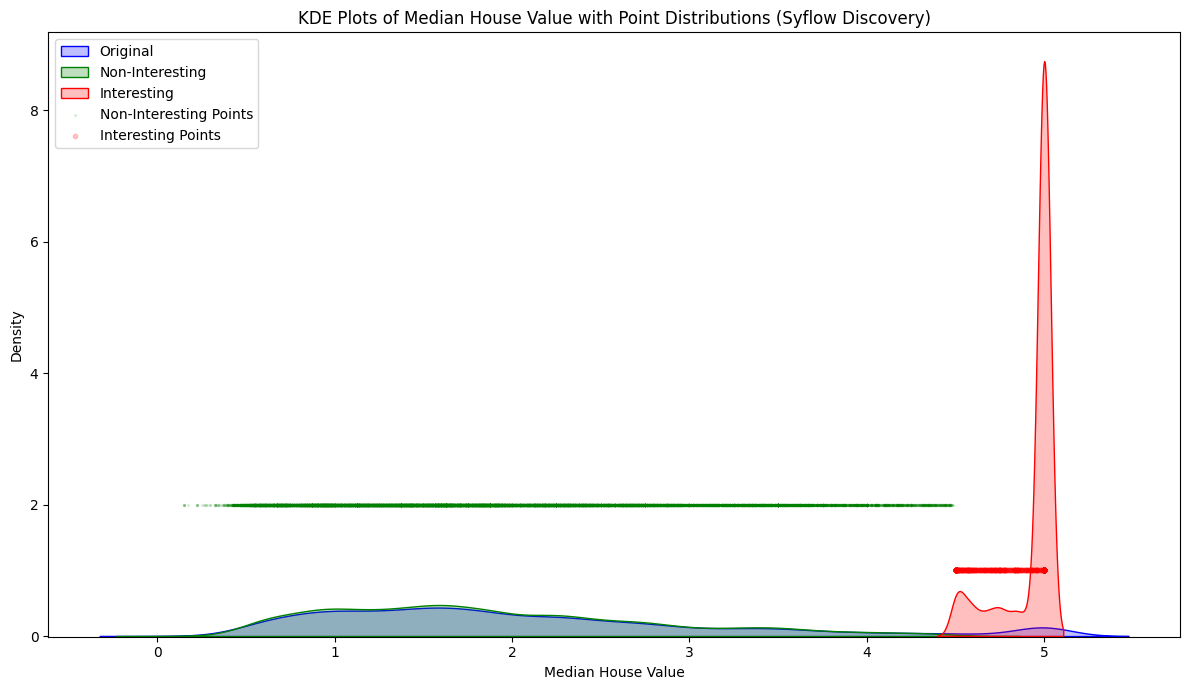

: 